In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e1/sample_submission.csv
/kaggle/input/playground-series-s6e1/train.csv
/kaggle/input/playground-series-s6e1/test.csv


# Librairies

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pickle
import joblib
import json
from datetime import datetime
import optuna

# EDA

In [3]:
dataset = pd.read_csv('/kaggle/input/playground-series-s6e1/train.csv').set_index('id')

In [4]:
dataset

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.300
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.700
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.000
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.900
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.000
...,...,...,...,...,...,...,...,...,...,...,...,...
629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500
629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900
629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 62.5+ MB


In [6]:
dataset.drop_duplicates()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.300
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.700
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.000
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.900
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.000
...,...,...,...,...,...,...,...,...,...,...,...,...
629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500
629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900
629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599


In [7]:
dataset.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,20.545821,4.002337,71.987261,7.072758,62.506672
std,2.260238,2.359880,17.430098,1.744811,18.916884
min,17.000000,0.080000,40.600000,4.100000,19.599000
25%,19.000000,1.970000,57.000000,5.600000,48.800000
50%,21.000000,4.000000,72.600000,7.100000,62.600000
75%,23.000000,6.050000,87.200000,8.600000,76.300000
max,24.000000,7.910000,99.400000,9.900000,100.000000


In [8]:
dataset.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

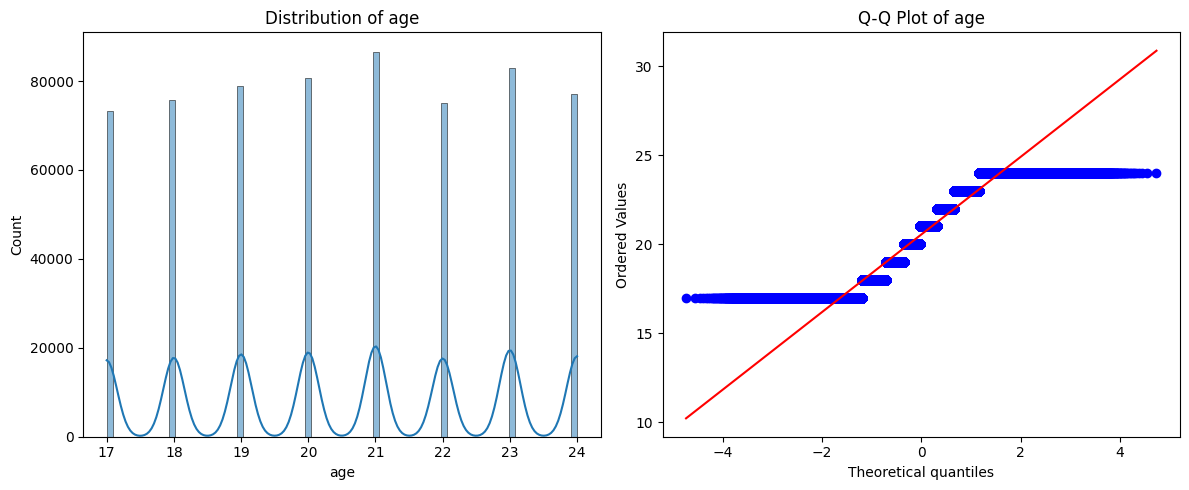

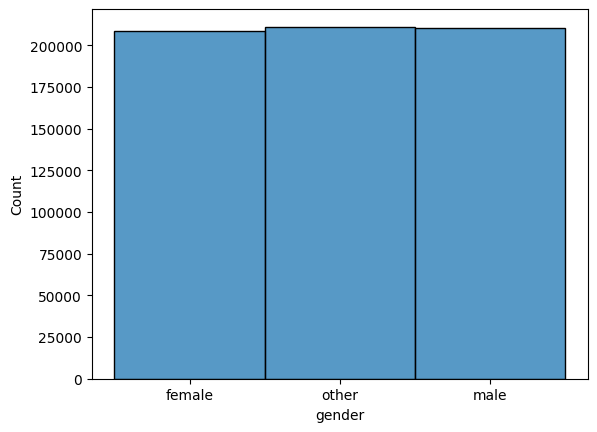

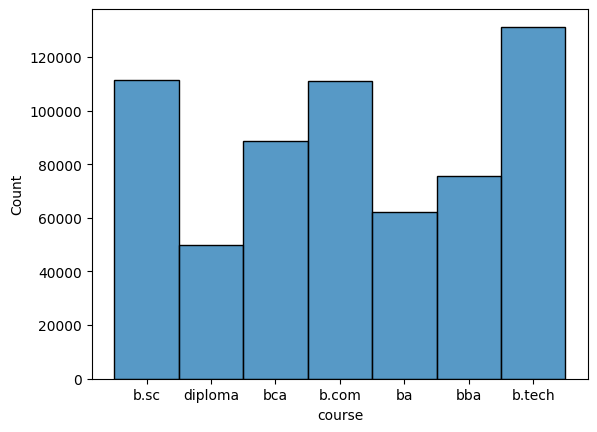

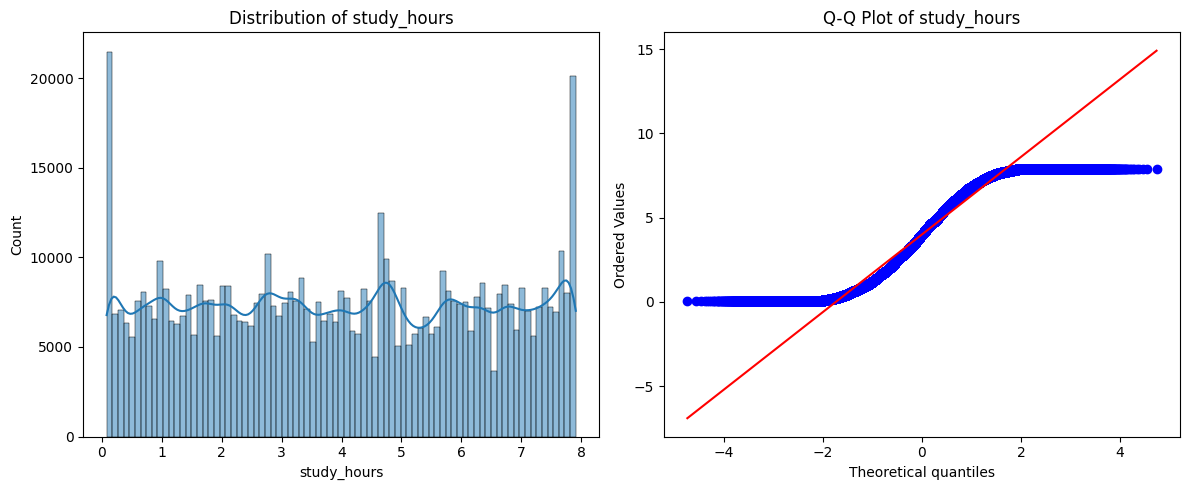

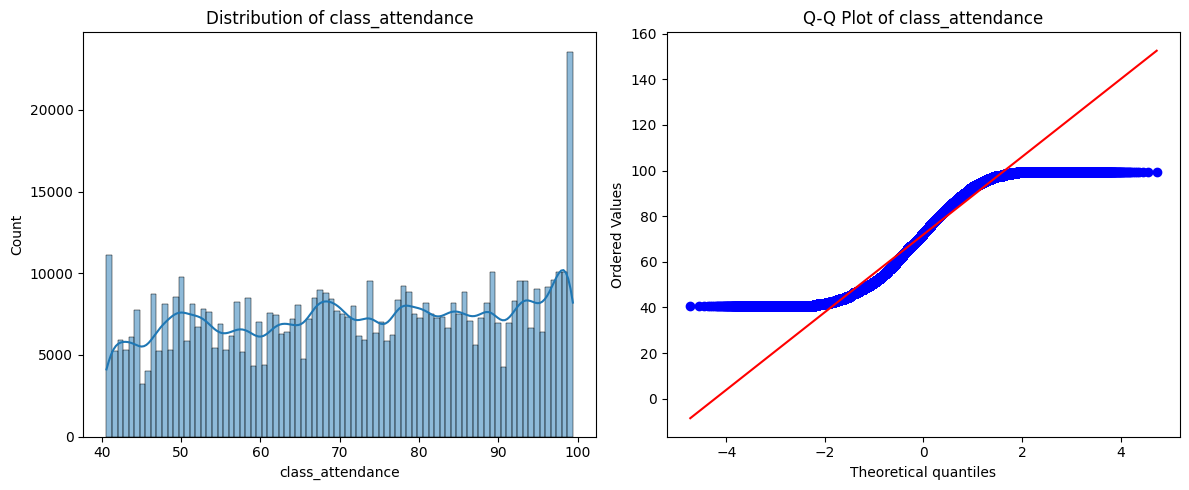

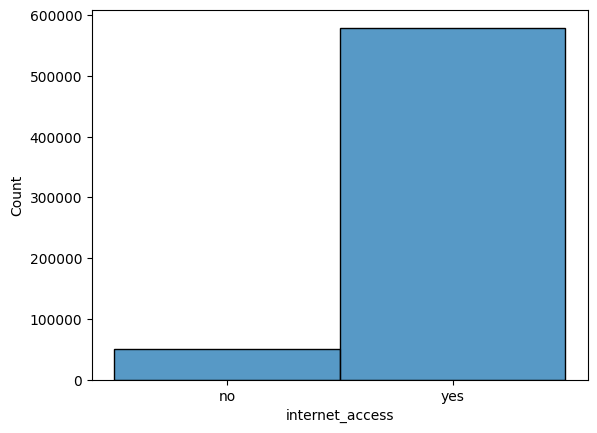

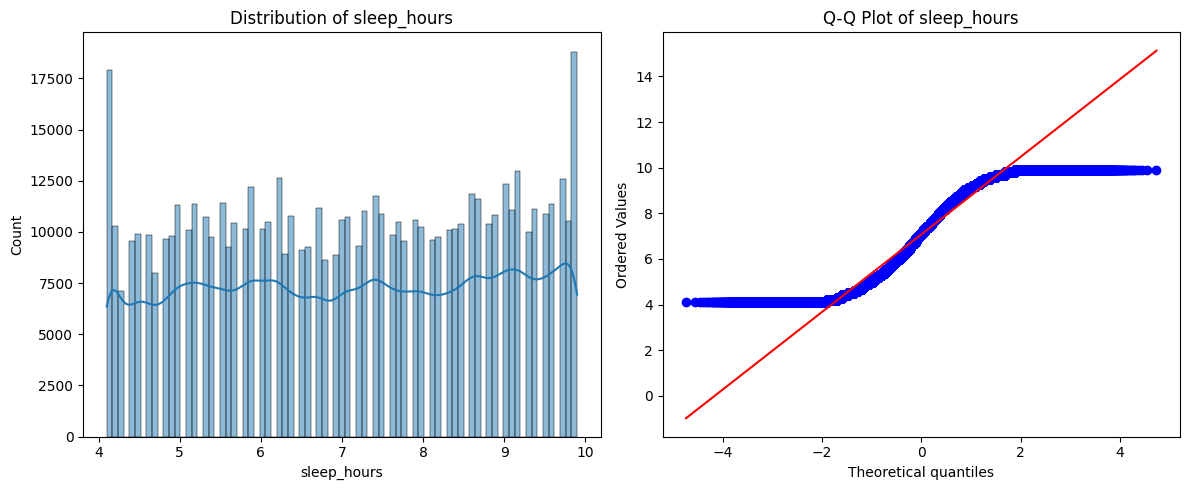

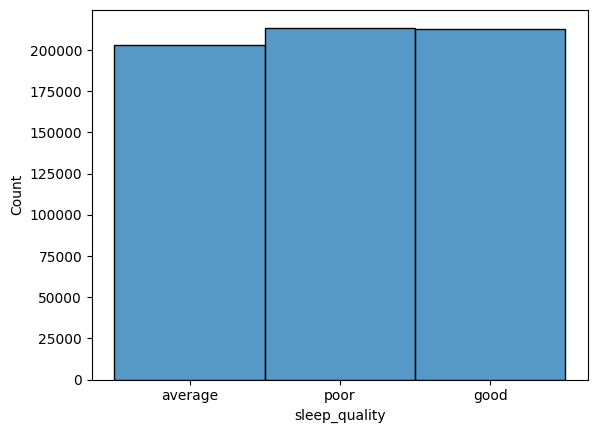

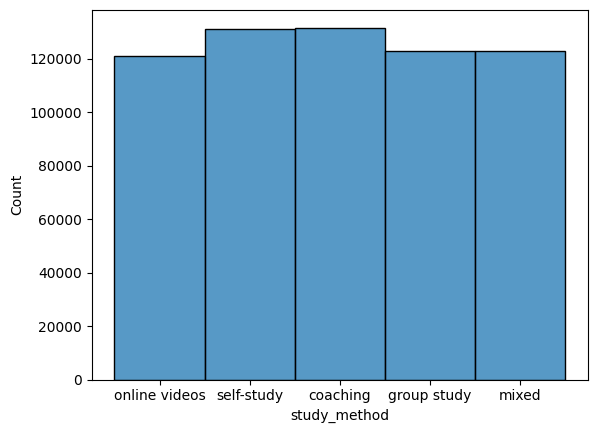

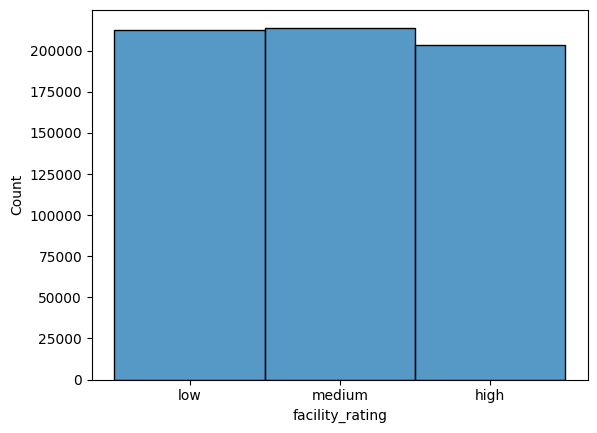

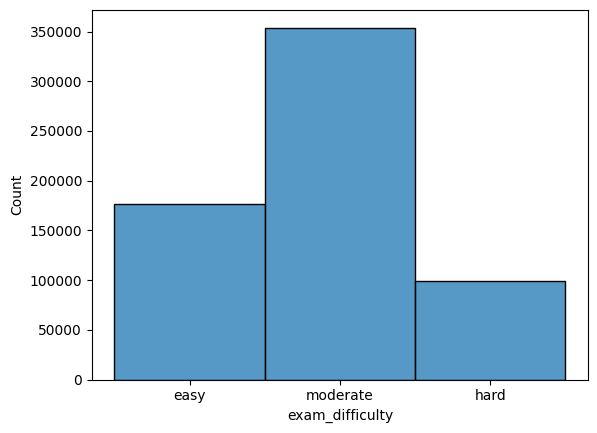

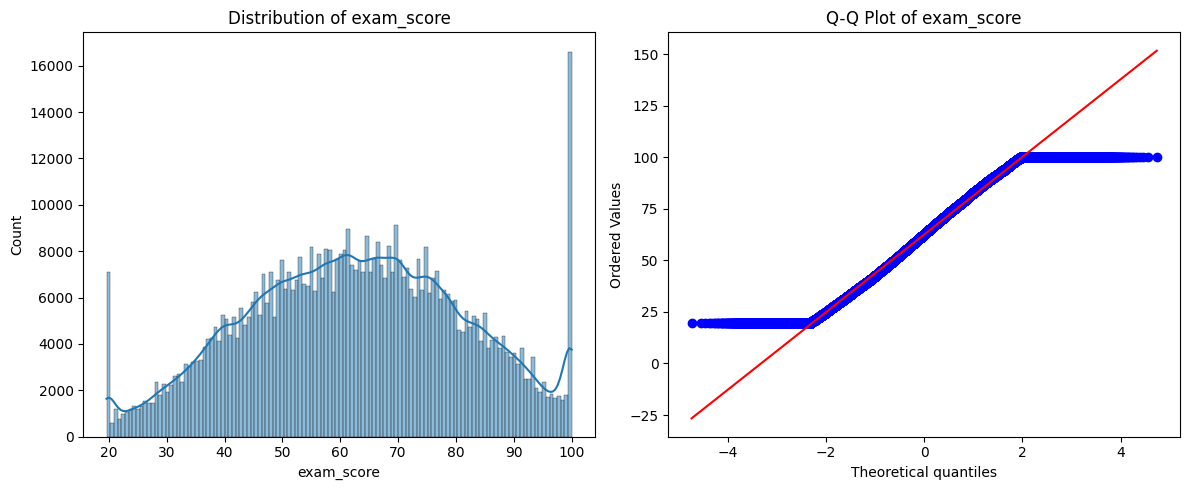

In [9]:
for col in dataset.columns:
    if dataset[col].dtype in ['int64', 'float64']:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        sns.histplot(data=dataset, x=col, kde=True, ax=ax1)
        ax1.set_title(f'Distribution of {col}')
        stats.probplot(dataset[col].dropna(), dist="norm", plot=ax2)
        ax2.set_title(f'Q-Q Plot of {col}')
        plt.tight_layout()
        plt.show()
    if dataset[col].dtype == 'object':
        sns.histplot(data=dataset, x=col)
        plt.show()

In [10]:
for col in dataset.columns:
    if dataset[col].dtype in ['int64', 'float64'] and col !="exam_score":
        print(f"Pearson correlation of 'exam_score'/'{col}':{dataset['exam_score'].corr(dataset[col], method='pearson')}")
        print(f"Spearman correlation of 'exam_score'/'{col}':{dataset['exam_score'].corr(dataset[col], method='spearman')}")

Pearson correlation of 'exam_score'/'age':0.01047241129748402
Spearman correlation of 'exam_score'/'age':0.007163204282159061
Pearson correlation of 'exam_score'/'study_hours':0.7622673295024415
Spearman correlation of 'exam_score'/'study_hours':0.7697574865941025
Pearson correlation of 'exam_score'/'class_attendance':0.3609540874687522
Spearman correlation of 'exam_score'/'class_attendance':0.35151496194915305
Pearson correlation of 'exam_score'/'sleep_hours':0.16740997041768968
Spearman correlation of 'exam_score'/'sleep_hours':0.16004792880752652


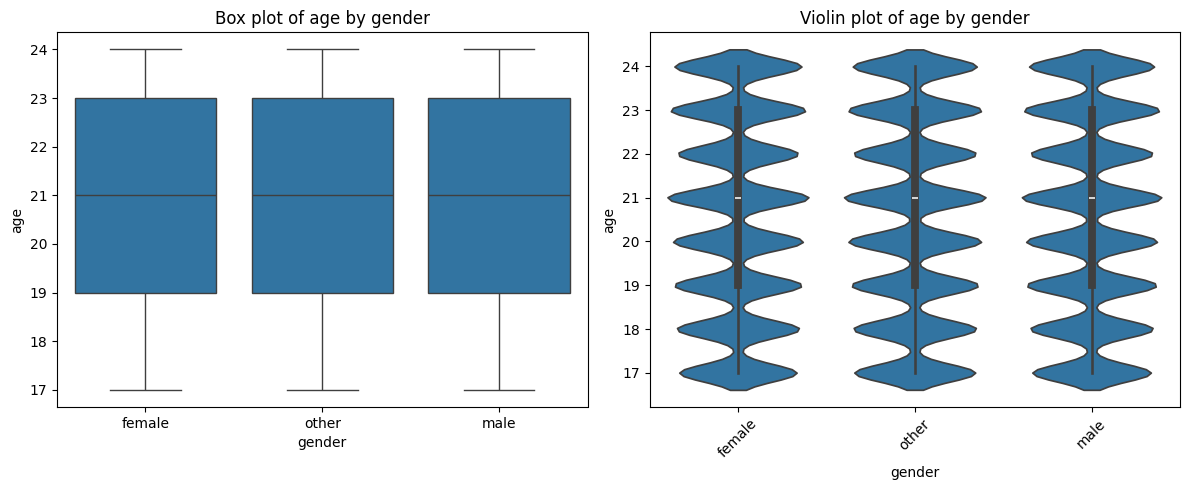

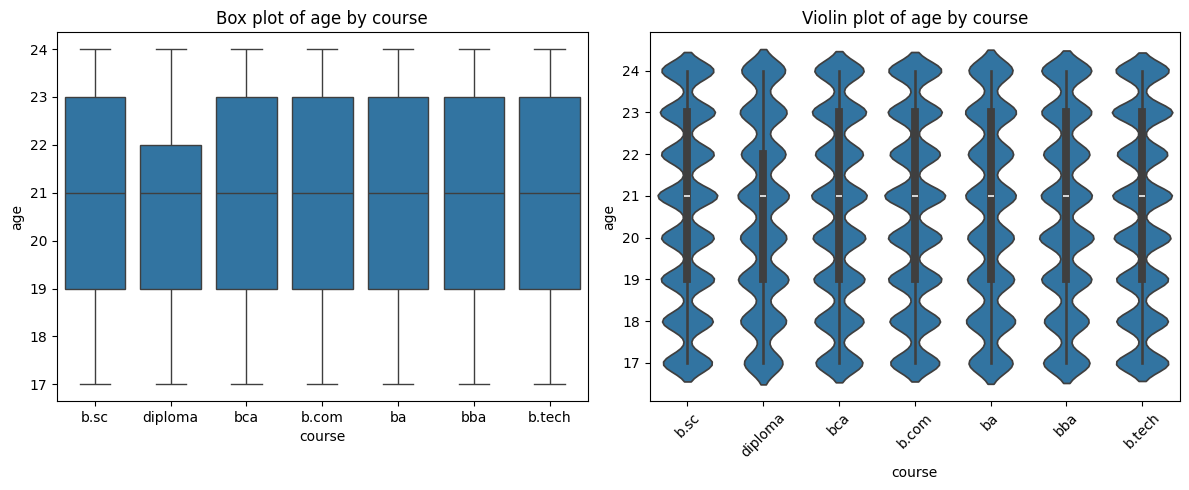

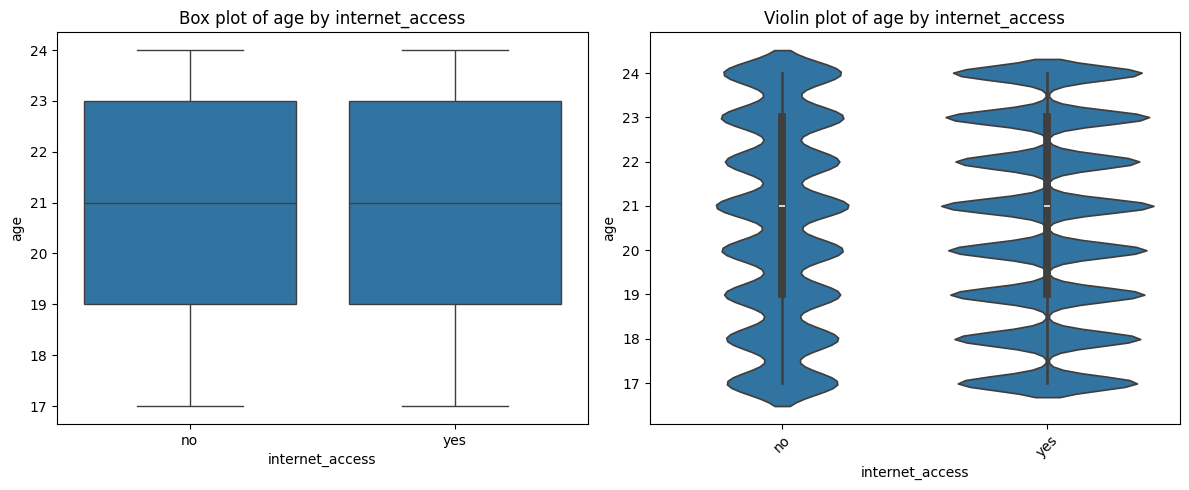

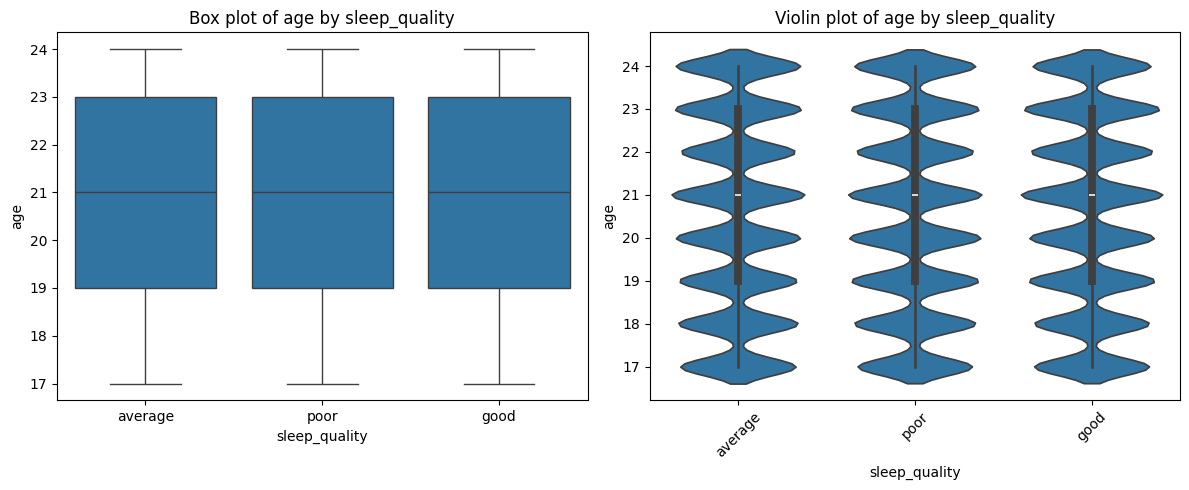

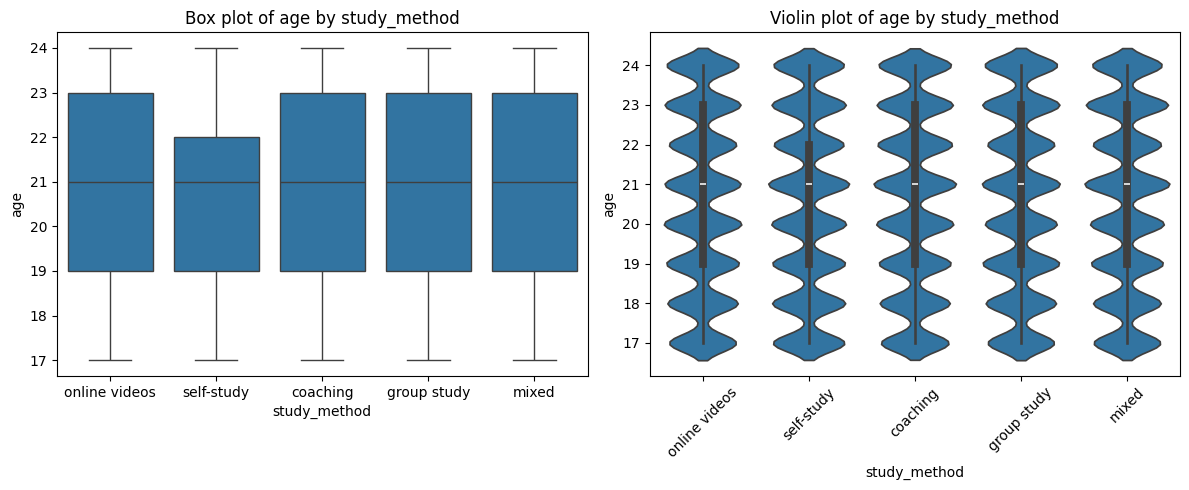

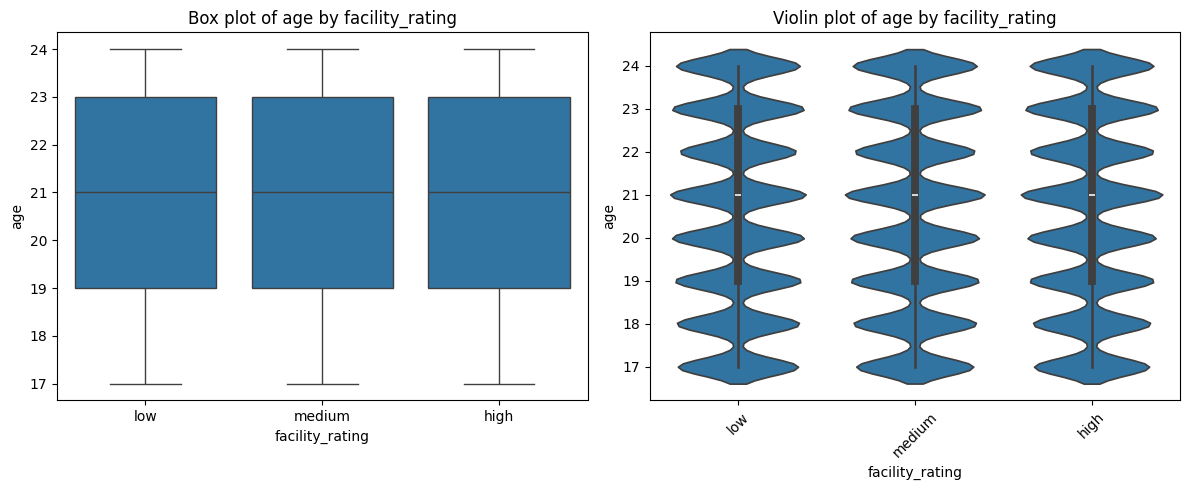

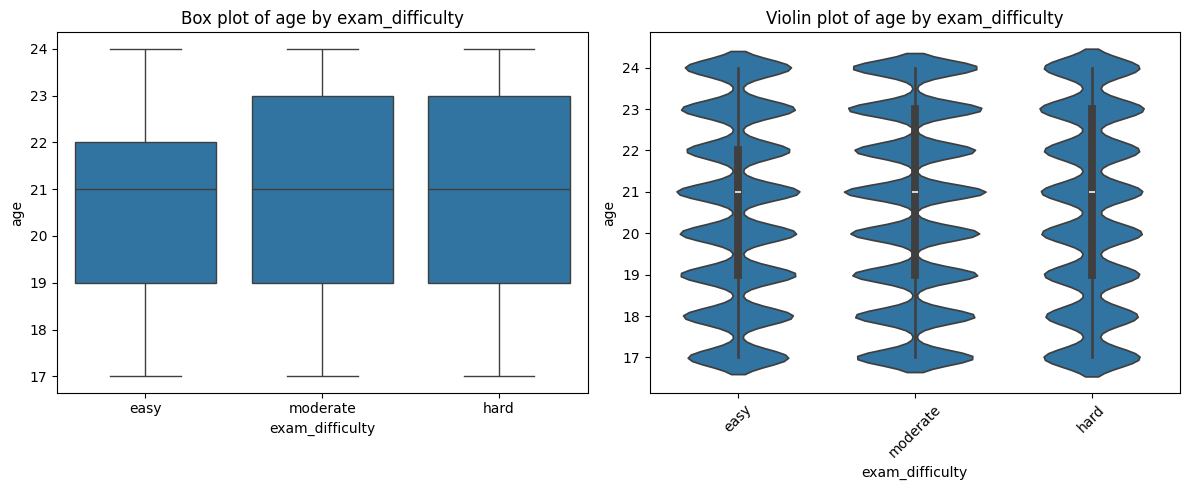

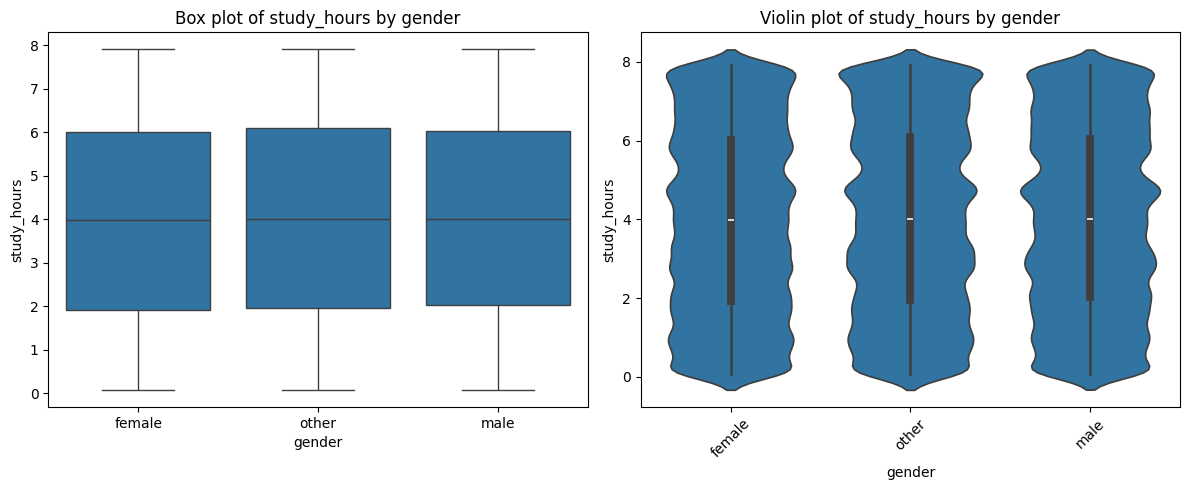

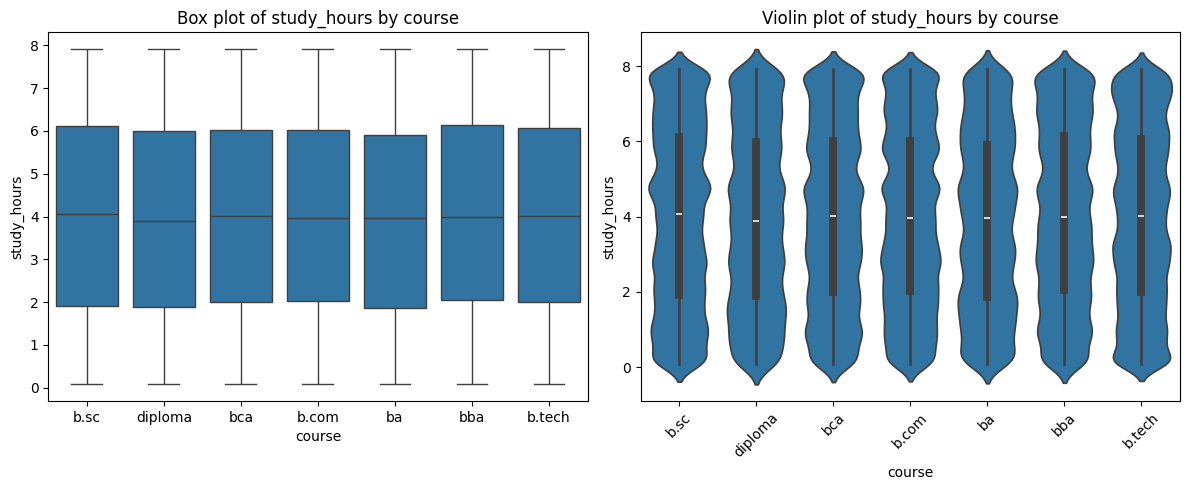

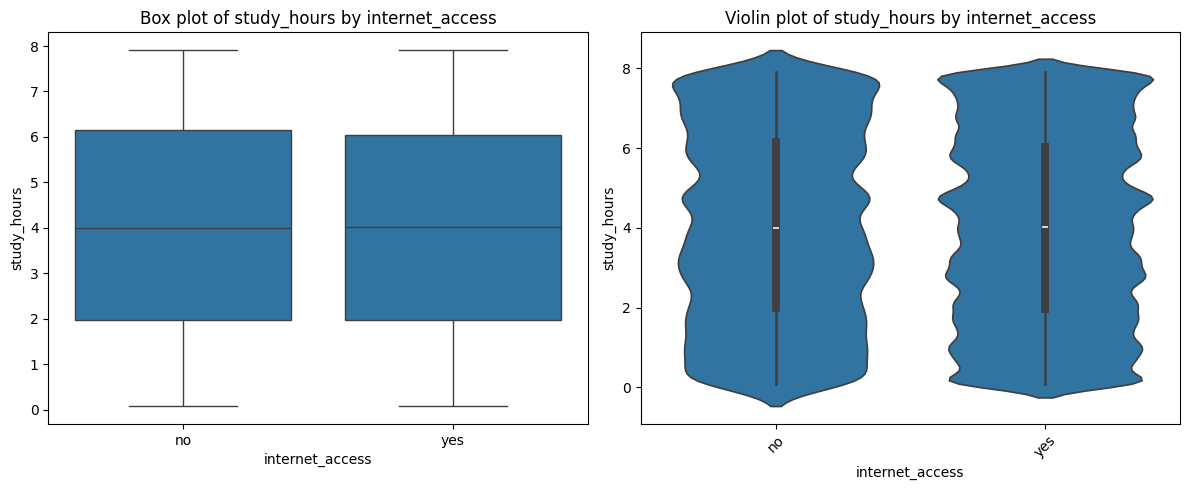

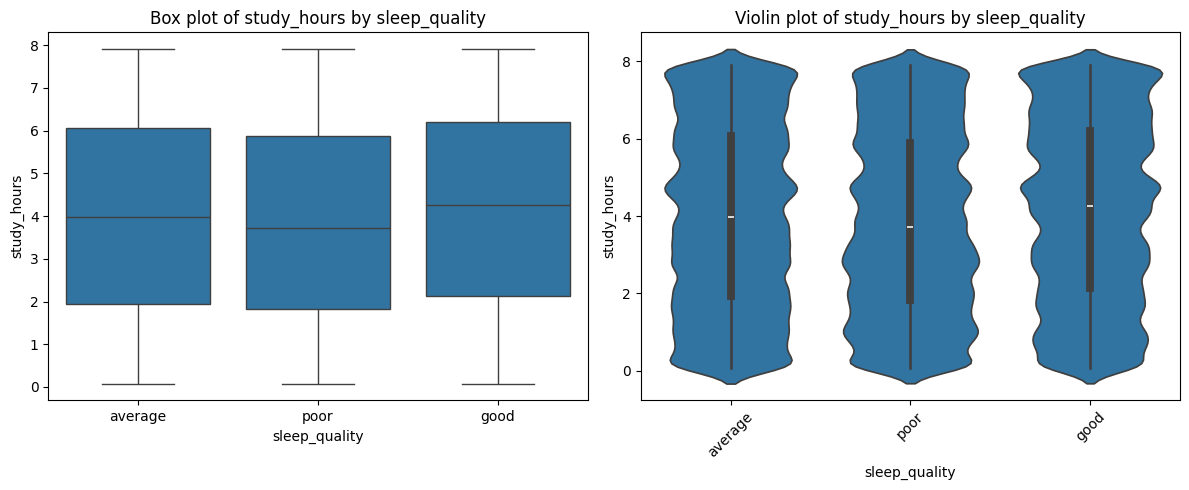

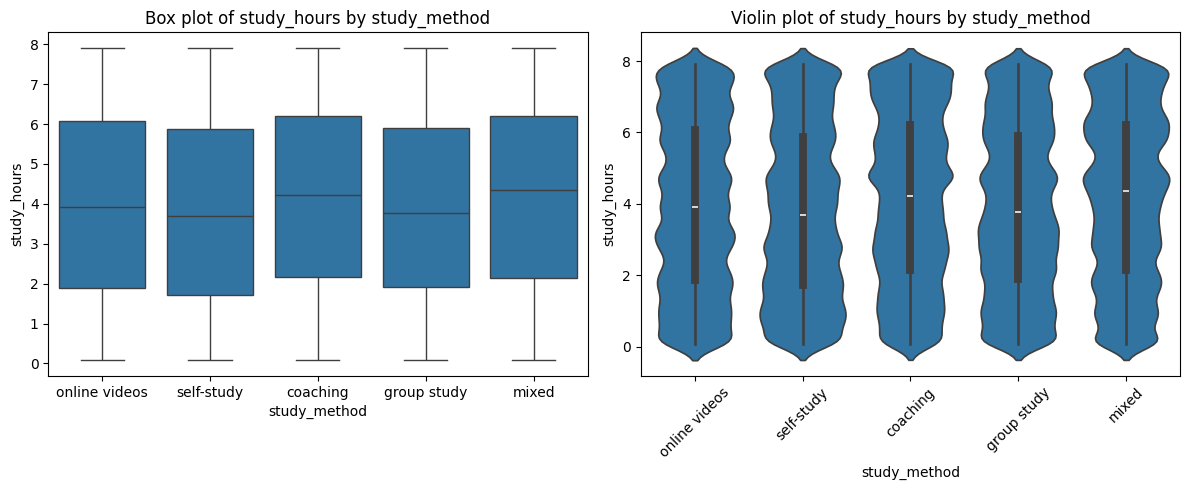

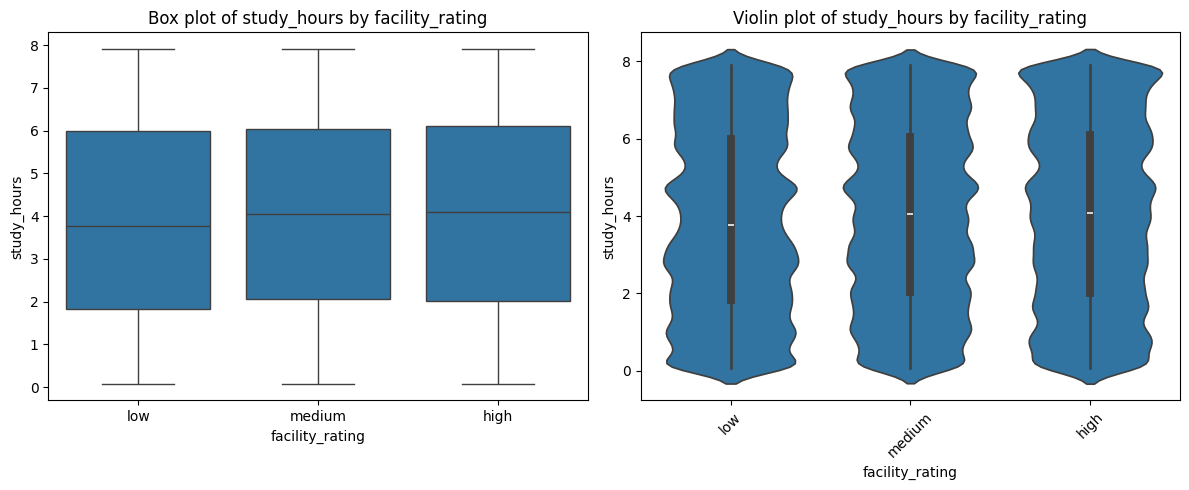

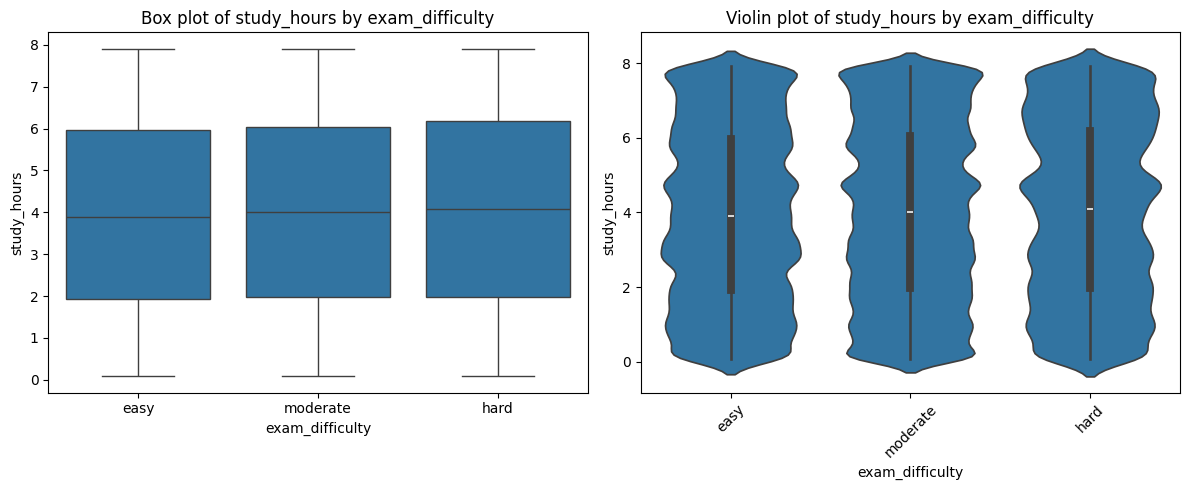

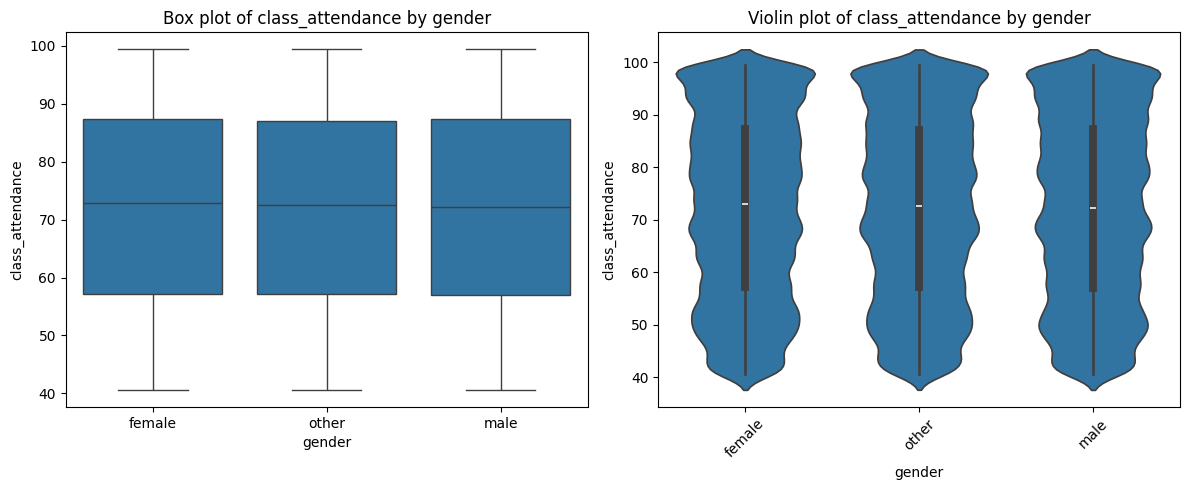

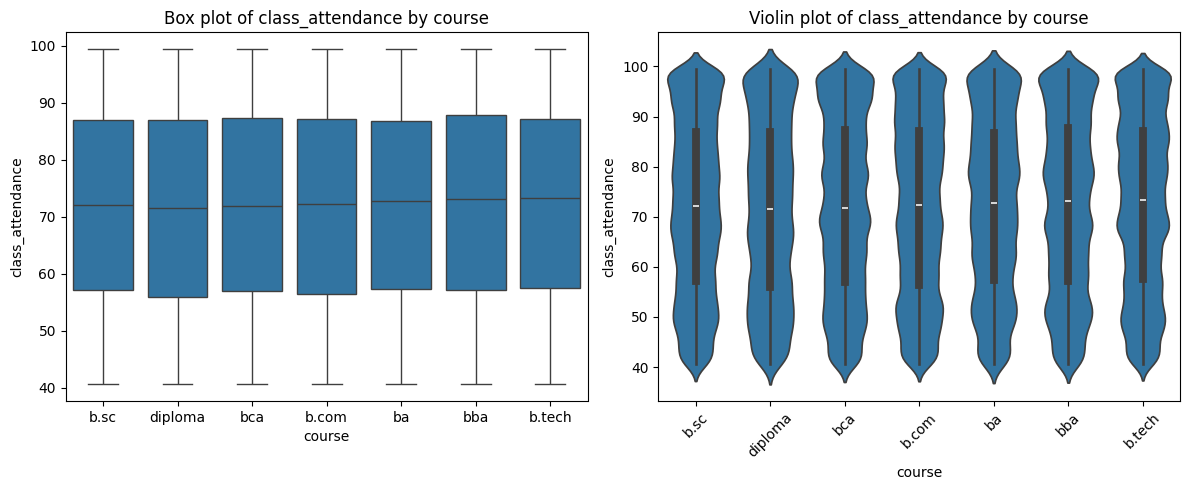

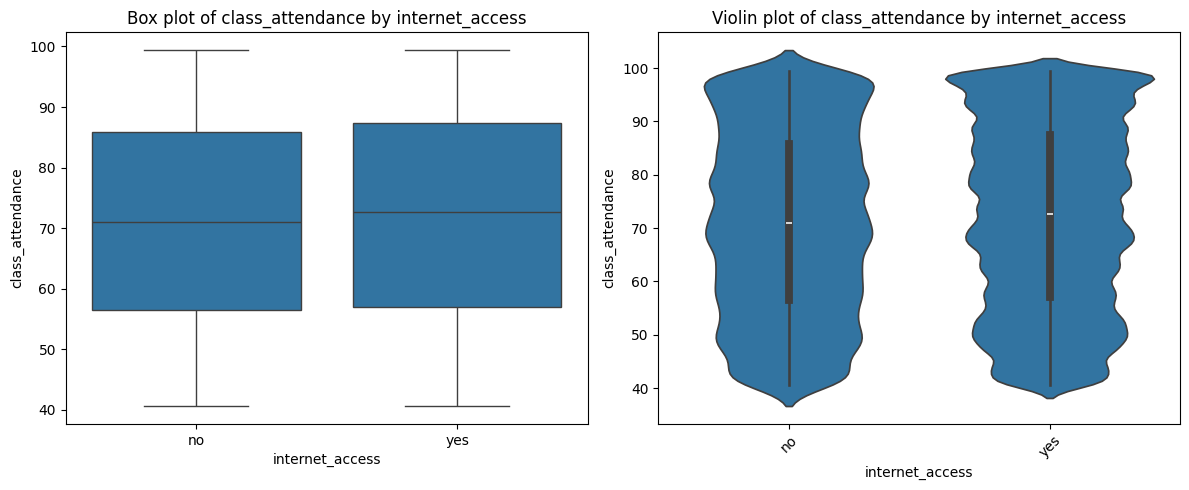

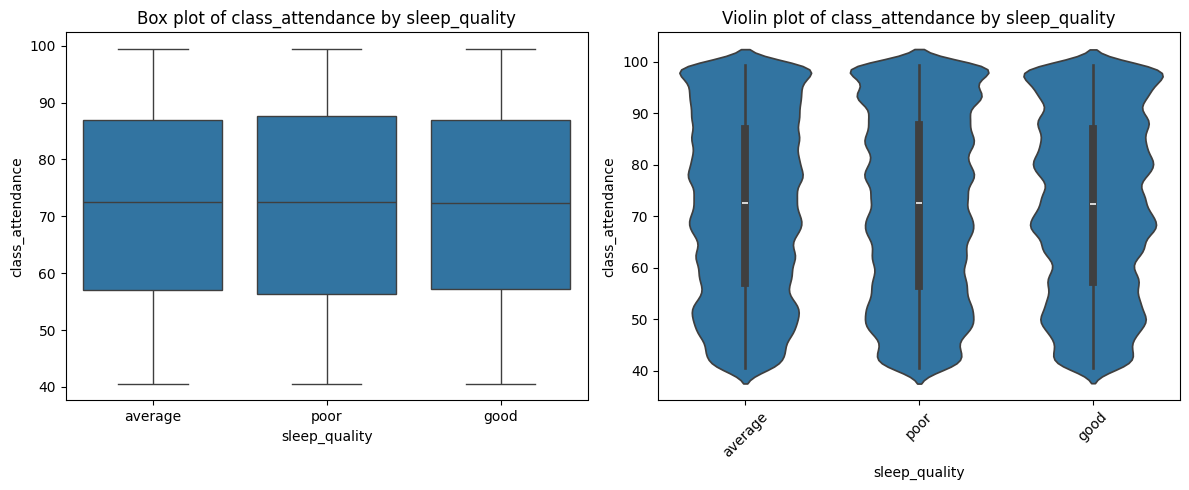

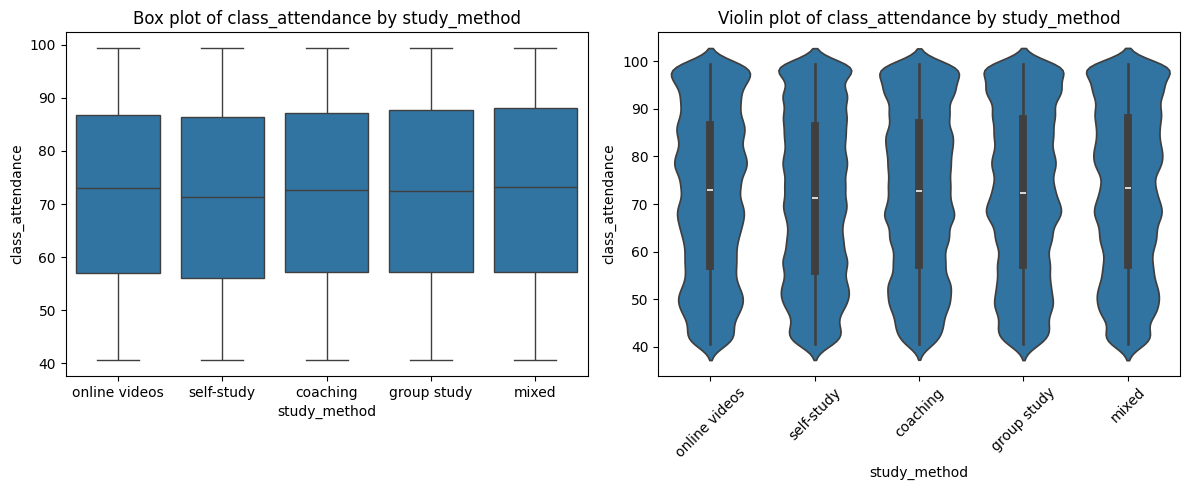

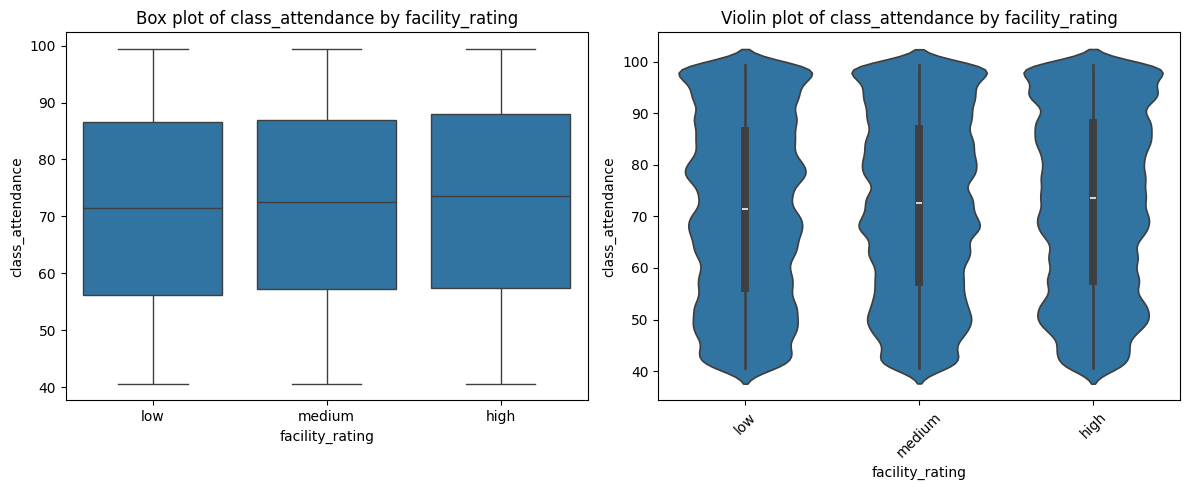

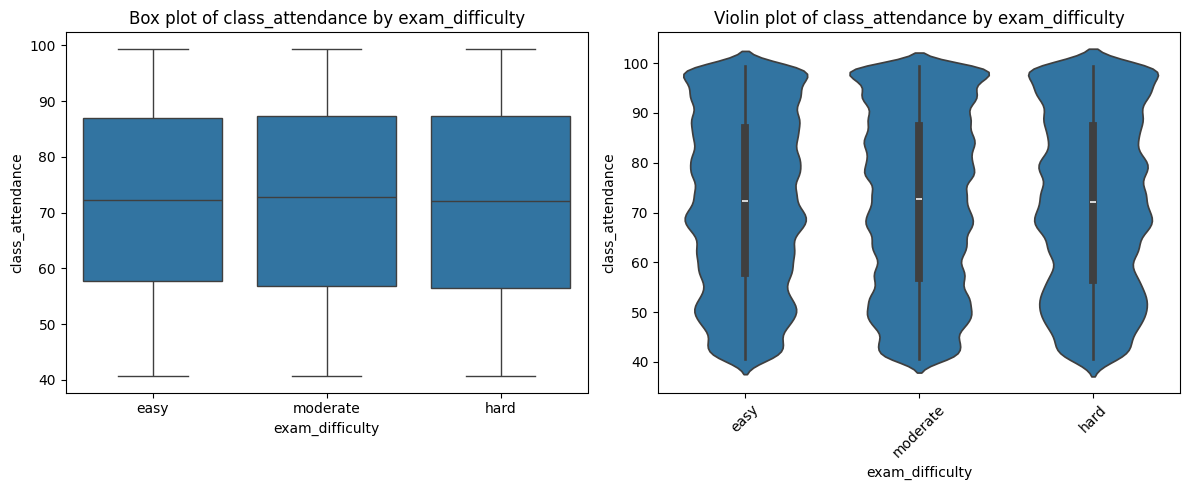

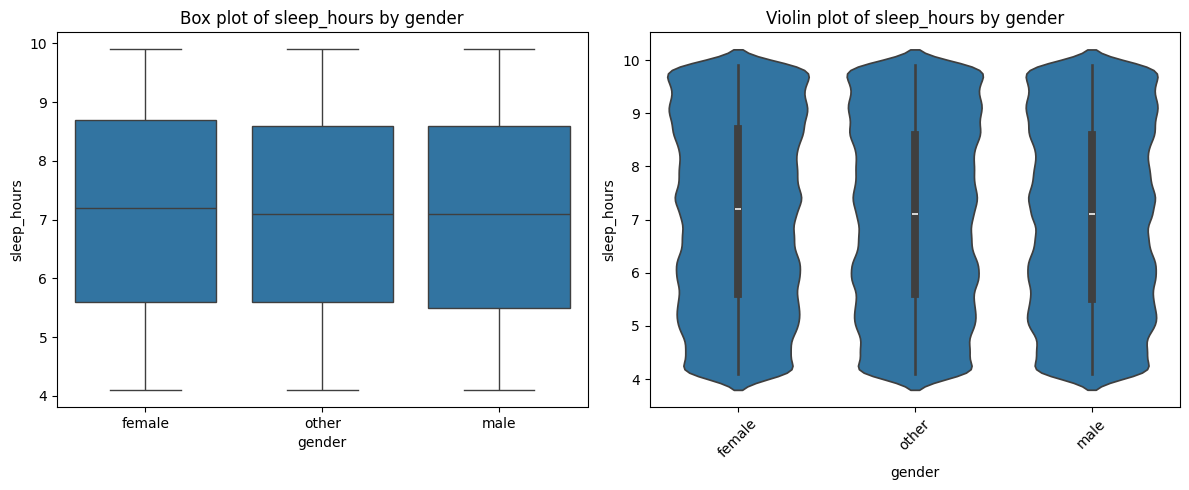

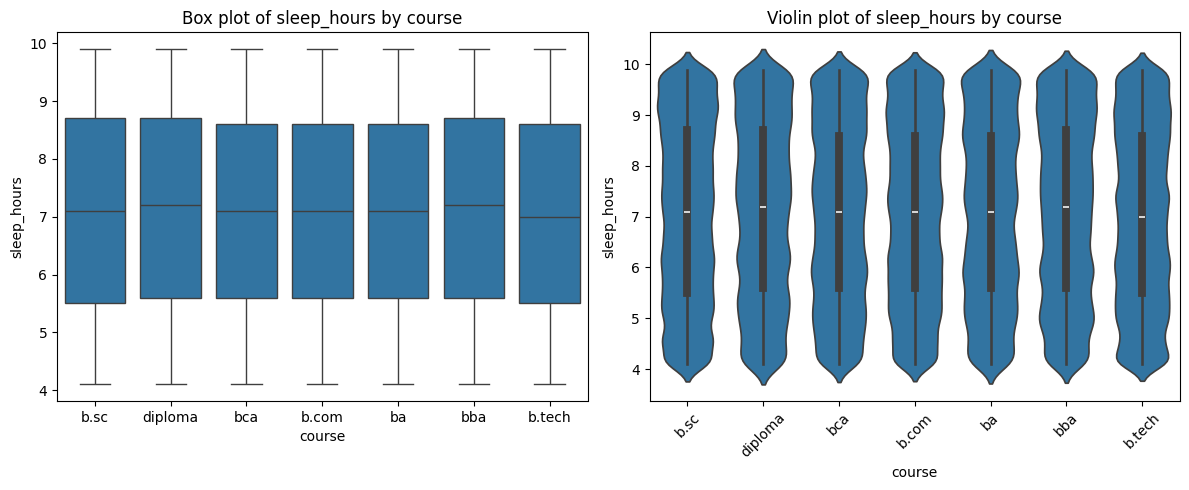

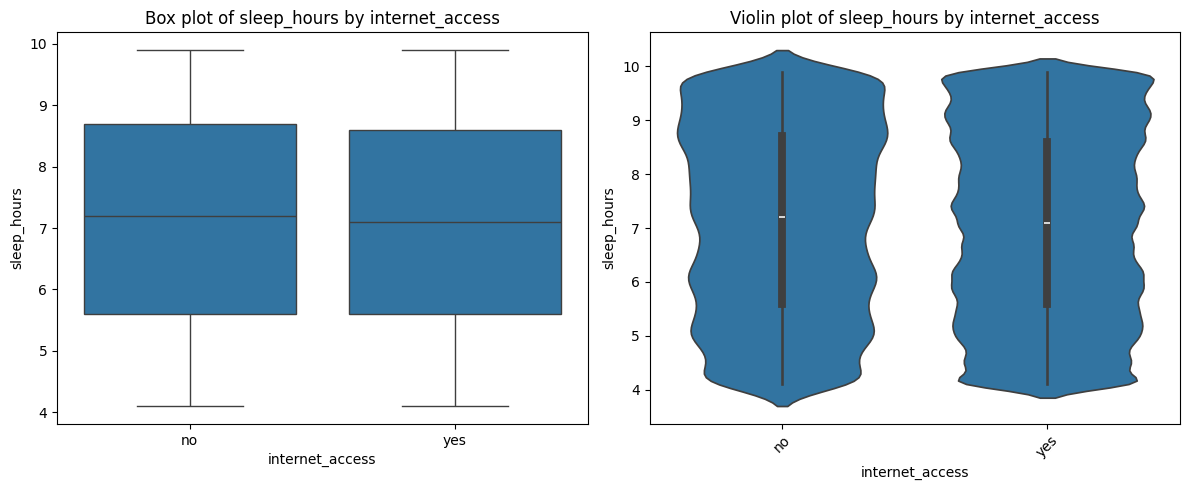

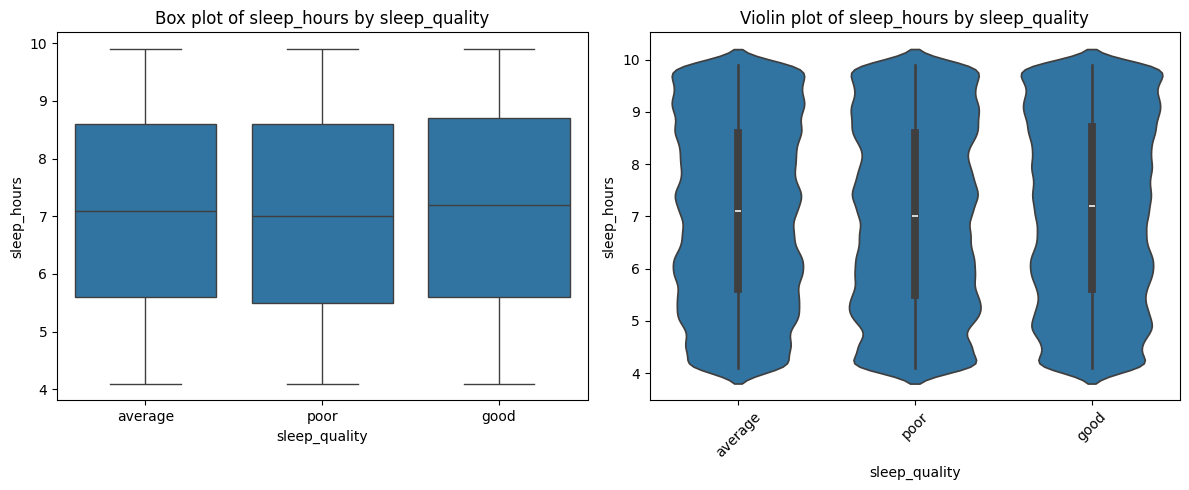

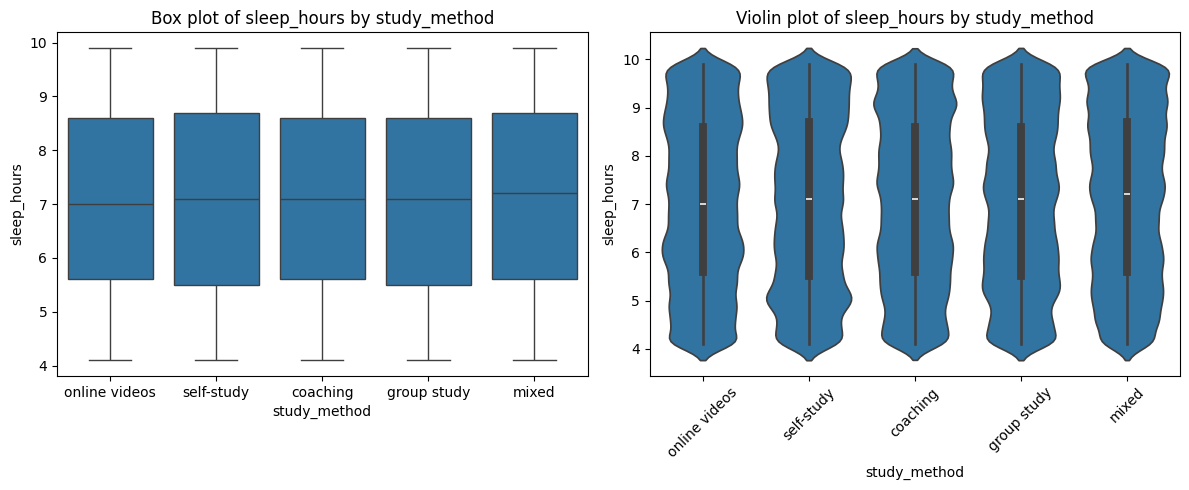

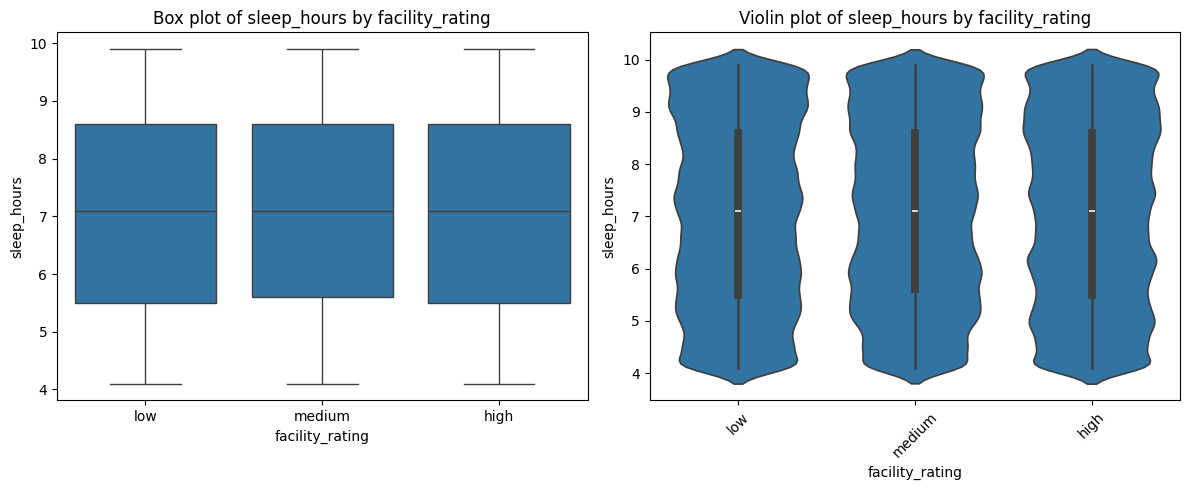

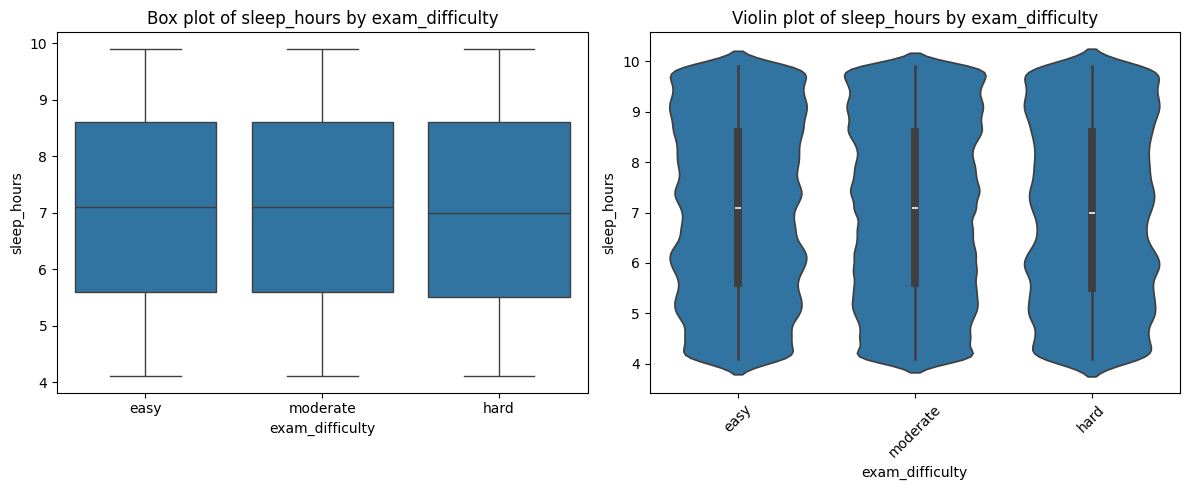

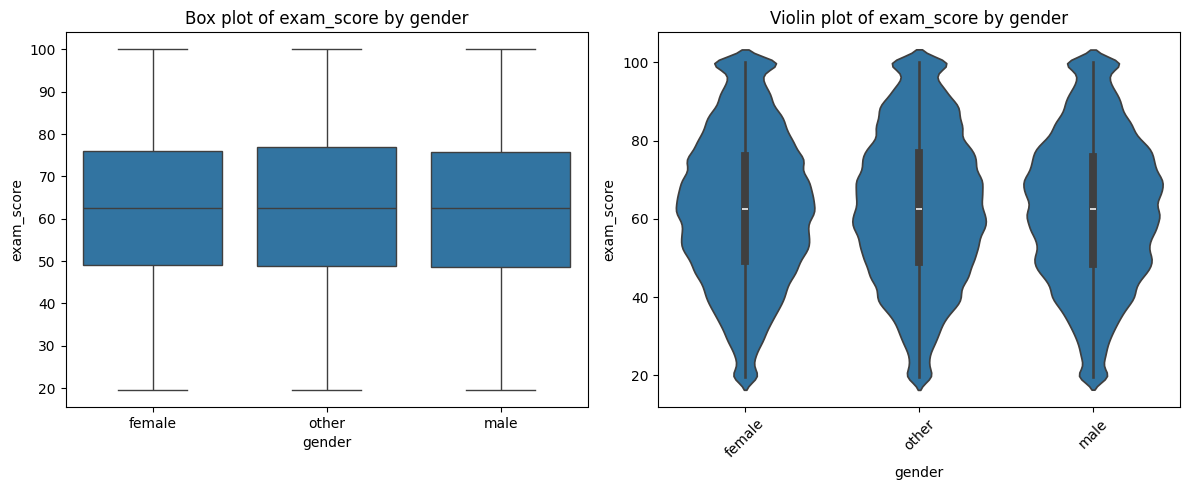

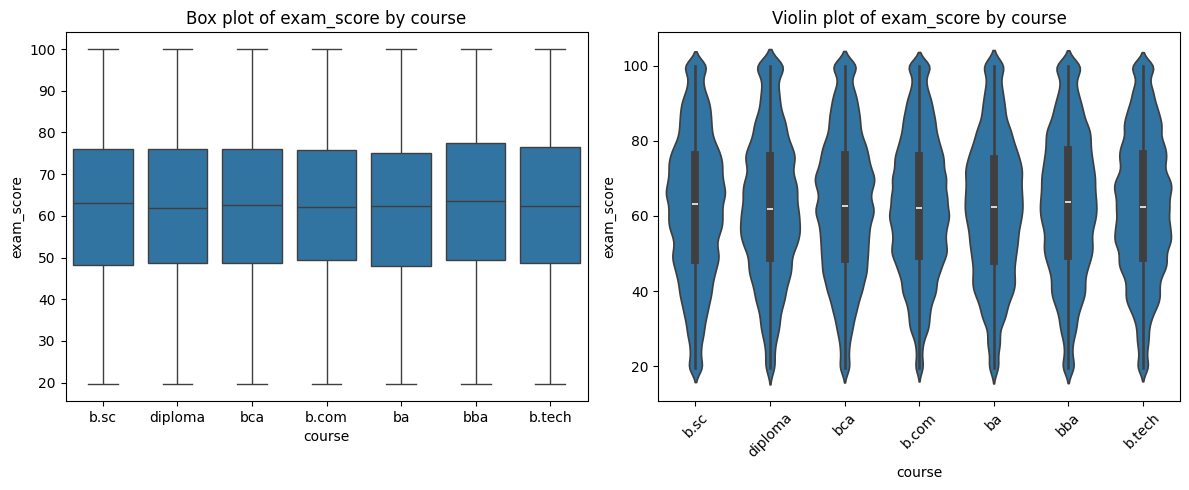

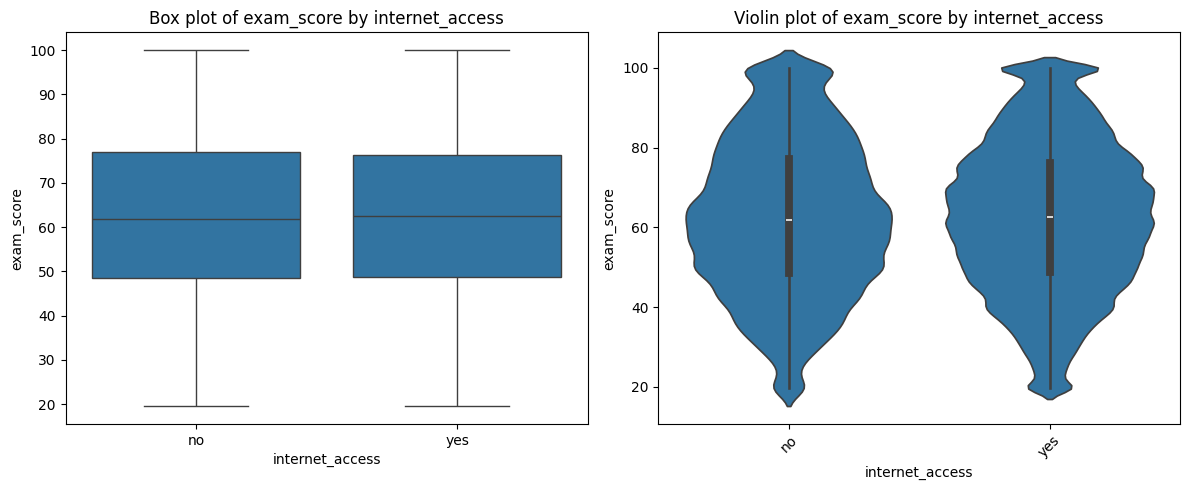

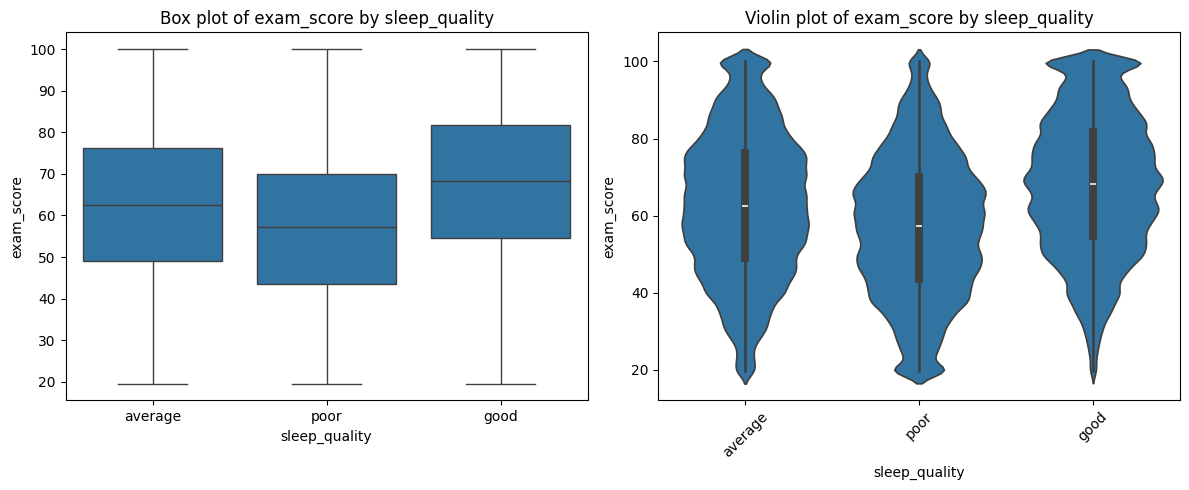

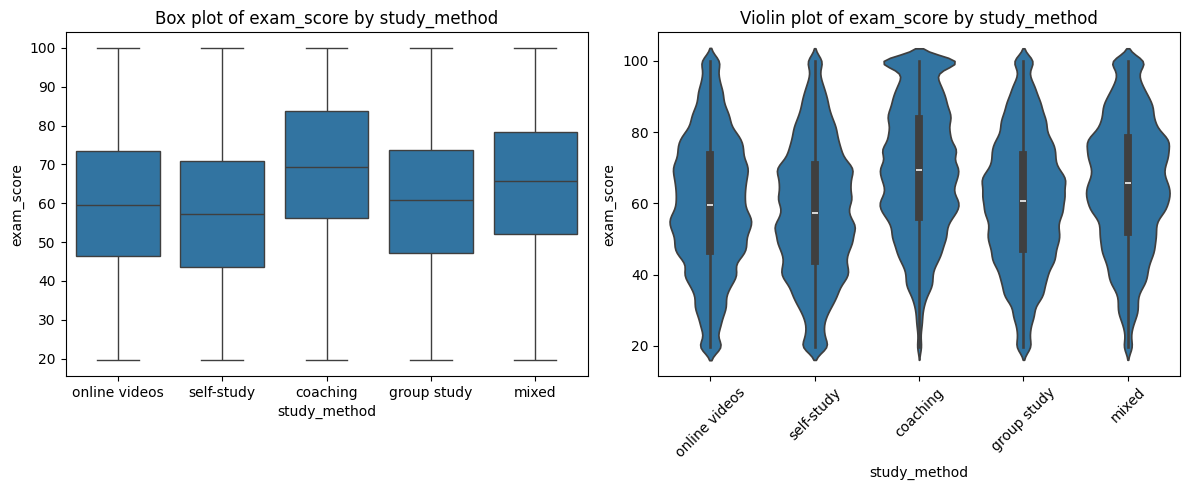

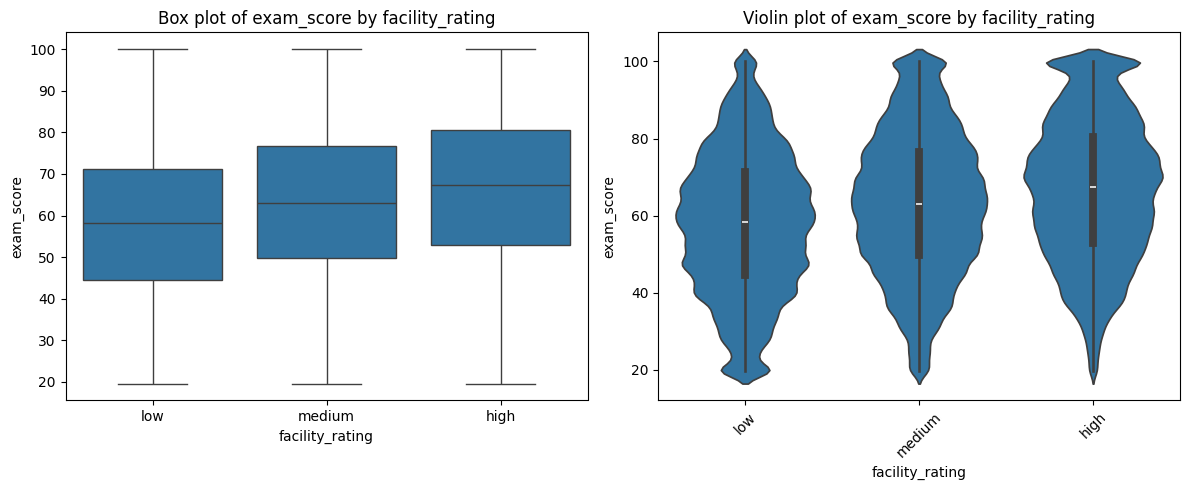

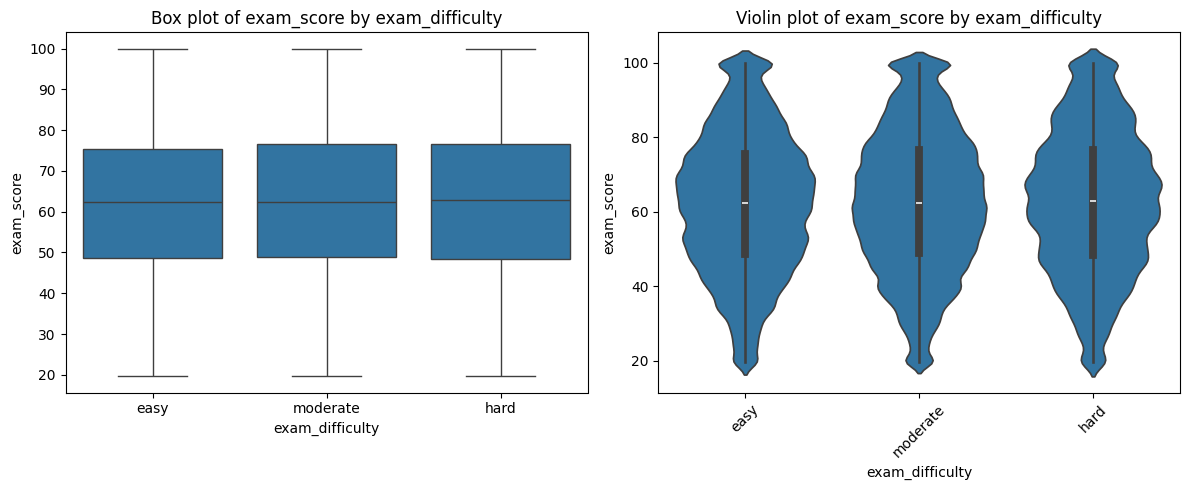

In [11]:
num_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
cat_cols = dataset.select_dtypes(include=['object']).columns

for num_col in num_cols:
    for cat_col in cat_cols:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        sns.boxplot(data=dataset, y=num_col, x=cat_col, ax=ax1)
        ax1.set_title(f'Box plot of {num_col} by {cat_col}')
        sns.violinplot(data=dataset, y=num_col, x=cat_col, ax=ax2)
        ax2.set_title(f'Violin plot of {num_col} by {cat_col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [12]:
for num_col in num_cols:
# Perform Shapiro-Wilk test
    print(num_col)
    statistic, p_value = stats.shapiro(dataset[num_col])
    
    print(f"Shapiro-Wilk statistic: {statistic}")
    print(f"p-value: {p_value}")
    
    # Interpret results
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject H0: Data looks normally distributed")
    else:
        print("Reject H0: Data does not look normally distributed")

age
Shapiro-Wilk statistic: 0.9293258284706799
p-value: 8.210289180243801e-137
Reject H0: Data does not look normally distributed
study_hours
Shapiro-Wilk statistic: 0.9516782520054861
p-value: 2.2078797172358898e-125
Reject H0: Data does not look normally distributed
class_attendance
Shapiro-Wilk statistic: 0.9523666317137878
p-value: 5.826568728694642e-125
Reject H0: Data does not look normally distributed
sleep_hours
Shapiro-Wilk statistic: 0.9506979241762948
p-value: 5.660334976623691e-126
Reject H0: Data does not look normally distributed
exam_score
Shapiro-Wilk statistic: 0.9895644677659794
p-value: 1.9618170647675346e-84
Reject H0: Data does not look normally distributed


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 630000.
  res = hypotest_fun_out(*samples, **kwds)


In [13]:
sample = dataset.sample(5000)

In [14]:
for num_col in num_cols:
# Perform Shapiro-Wilk test
    print(num_col)
    statistic, p_value = stats.shapiro(sample[num_col])
    
    print(f"Shapiro-Wilk statistic: {statistic}")
    print(f"p-value: {p_value}")
    
    # Interpret results
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject H0: Data looks normally distributed")
    else:
        print("Reject H0: Data does not look normally distributed")

age
Shapiro-Wilk statistic: 0.9291160476423466
p-value: 1.3505043718640615e-43
Reject H0: Data does not look normally distributed
study_hours
Shapiro-Wilk statistic: 0.953904958308466
p-value: 4.524340947843301e-37
Reject H0: Data does not look normally distributed
class_attendance
Shapiro-Wilk statistic: 0.9510257647647045
p-value: 5.890758290859587e-38
Reject H0: Data does not look normally distributed
sleep_hours
Shapiro-Wilk statistic: 0.9537750635562237
p-value: 4.117900596013146e-37
Reject H0: Data does not look normally distributed
exam_score
Shapiro-Wilk statistic: 0.9889414025452717
p-value: 2.3084562887030715e-19
Reject H0: Data does not look normally distributed


In [15]:
y = dataset['exam_score']
X = dataset.drop('exam_score', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## FEATURE ENGINEERING

In [16]:
def engineer_features(df):
    # Create new features
    df = df.copy()
    df['study_efficiency'] = df['study_hours'] * df['class_attendance'] / 100
    df['sleep_study_ratio'] = df['study_hours'] / (df['sleep_hours'] + 0.001)  # avoid division by zero
    
    # Binning
    df['age_group'] = pd.cut(df['age'], bins=[16, 19, 22, 25], labels=['teen', 'young_adult', 'adult'])
    df['study_hours_category'] = pd.cut(df['study_hours'], bins=[0, 3, 6, 10], labels=['low', 'medium', 'high'])
    
    # Ordinal encoding for ordinal variables
    sleep_quality_map = {'poor': 0, 'average': 1, 'good': 2}
    facility_map = {'low': 0, 'medium': 1, 'high': 2}
    difficulty_map = {'easy': 0, 'moderate': 1, 'hard': 2}
    study_map = {'low': 0, 'medium': 1, 'high': 2}
    age_map = {'teen': 0, 'young_adult': 1, 'adult': 2}
    
    df['sleep_quality_encoded'] = df['sleep_quality'].map(sleep_quality_map)
    df['facility_rating_encoded'] = df['facility_rating'].map(facility_map)
    df['exam_difficulty_encoded'] = df['exam_difficulty'].map(difficulty_map)
    df['study_hours_category_encoded'] = df['study_hours_category'].map(study_map).astype('int64')
    df['age_group_encoded'] = df['age_group'].map(age_map).astype('int64')
    
    # Binary encoding
    df = pd.get_dummies(df, columns =['gender', 'course', 'study_method', 'internet_access'], drop_first=True)

    df.drop(columns=['sleep_quality', 'facility_rating', 'exam_difficulty', 'age_group', 'study_hours_category'], axis=1, inplace=True)
    
    # Target encoding (if you have target variable)
    if 'exam_score' in df.columns:
        course_mean_score = df.groupby('course')['exam_score'].mean().to_dict()
        df['course_mean_score'] = df['course'].map(course_mean_score)
        
        method_mean_score = df.groupby('study_method')['exam_score'].mean().to_dict()
        df['method_mean_score'] = df['study_method'].map(method_mean_score)
    
    # Interaction features
    df['attendance_sleep_interaction'] = df['class_attendance'] * df['sleep_quality_encoded']
    
    # Polynomial features
    df['study_hours_squared'] = df['study_hours'] ** 2
    df['attendance_squared'] = df['class_attendance'] ** 2
    
    return df

In [17]:
X_train_v2 = engineer_features(X_train)

In [18]:
X_train_v2

,age,study_hours,class_attendance,sleep_hours,study_efficiency,sleep_study_ratio,sleep_quality_encoded,facility_rating_encoded,exam_difficulty_encoded,study_hours_category_encoded,...,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,internet_access_yes,attendance_sleep_interaction,study_hours_squared,attendance_squared
id,,,,,,,,,,,,,,,,,,,,,
625149,20,0.84,79.0,9.9,0.66360,0.084840,2,0,2,0,...,False,False,False,True,False,False,True,158.0,0.7056,6241.00
276435,19,3.35,94.2,6.0,3.15570,0.558240,2,1,1,1,...,False,False,True,False,False,False,True,188.4,11.2225,8873.64
43949,18,2.20,87.5,6.8,1.92500,0.323482,2,2,0,0,...,False,False,False,False,True,False,True,175.0,4.8400,7656.25
280523,18,3.10,64.0,7.6,1.98400,0.407841,1,1,1,1,...,True,False,False,False,False,True,True,64.0,9.6100,4096.00
619977,22,1.44,56.2,5.5,0.80928,0.261771,1,1,2,0,...,False,True,False,False,True,False,True,56.2,2.0736,3158.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,21,2.88,93.4,6.1,2.68992,0.472054,0,0,1,0,...,False,False,False,False,False,True,True,0.0,8.2944,8723.56
259178,20,6.90,74.5,4.3,5.14050,1.604278,1,1,1,2,...,True,False,False,False,True,False,True,74.5,47.6100,5550.25
365838,20,1.54,59.3,8.4,0.91322,0.183312,2,0,2,0,...,False,False,False,True,False,False,True,118.6,2.3716,3516.49


In [19]:
X_train_v2.select_dtypes(include=['int64','float64']).columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours',
       'study_efficiency', 'sleep_study_ratio', 'sleep_quality_encoded',
       'facility_rating_encoded', 'exam_difficulty_encoded',
       'study_hours_category_encoded', 'age_group_encoded',
       'attendance_sleep_interaction', 'study_hours_squared',
       'attendance_squared'],
      dtype='object')

In [20]:
X_test_v2 = engineer_features(X_test)

In [21]:
X_test_v2

,age,study_hours,class_attendance,sleep_hours,study_efficiency,sleep_study_ratio,sleep_quality_encoded,facility_rating_encoded,exam_difficulty_encoded,study_hours_category_encoded,...,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,internet_access_yes,attendance_sleep_interaction,study_hours_squared,attendance_squared
id,,,,,,,,,,,,,,,,,,,,,
364426,18,3.07,88.3,4.1,2.71081,0.748598,1,0,2,1,...,False,False,False,False,False,False,True,88.3,9.4249,7796.89
224752,21,3.28,49.6,7.0,1.62688,0.468504,0,2,1,1,...,False,False,False,False,True,False,False,0.0,10.7584,2460.16
110423,20,4.45,42.5,6.7,1.89125,0.664080,2,2,1,1,...,True,False,True,False,False,False,True,85.0,19.8025,1806.25
272555,21,4.19,82.8,5.7,3.46932,0.734959,0,0,2,1,...,False,False,False,True,False,False,True,0.0,17.5561,6855.84
199651,21,1.31,91.2,8.5,1.19472,0.154100,0,0,0,0,...,False,False,False,True,False,False,True,0.0,1.7161,8317.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514830,17,0.28,55.7,4.8,0.15596,0.058321,1,0,0,0,...,False,False,False,False,False,True,True,55.7,0.0784,3102.49
308756,18,6.92,84.0,9.2,5.81280,0.752092,2,2,2,2,...,False,False,False,False,False,False,True,168.0,47.8864,7056.00
608482,20,2.08,81.1,8.5,1.68688,0.244677,1,1,2,0,...,False,False,True,False,False,False,False,81.1,4.3264,6577.21


In [22]:
X_train_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504000 entries, 625149 to 121958
Data columns (total 27 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   age                           504000 non-null  int64  
 1   study_hours                   504000 non-null  float64
 2   class_attendance              504000 non-null  float64
 3   sleep_hours                   504000 non-null  float64
 4   study_efficiency              504000 non-null  float64
 5   sleep_study_ratio             504000 non-null  float64
 6   sleep_quality_encoded         504000 non-null  int64  
 7   facility_rating_encoded       504000 non-null  int64  
 8   exam_difficulty_encoded       504000 non-null  int64  
 9   study_hours_category_encoded  504000 non-null  int64  
 10  age_group_encoded             504000 non-null  int64  
 11  gender_male                   504000 non-null  bool   
 12  gender_other                  504000 non-nul

In [26]:
def simple_objective(trial):
    """
    Simple objective function for Optuna optimization
    """
    # Define parameters to optimize
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 15000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        
        # Fixed parameters
        'early_stopping_rounds': 100,
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_jobs': -1,
    }
    
    # Create model
    model = xgb.XGBRegressor(**params)
    
    # Train with early stopping
    model.fit(
        X_train_v2, y_train,
        eval_set=[(X_test_v2, y_test)],
        
        verbose=False
    )
    
    # Make predictions
    y_pred = model.predict(X_test_v2)
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return rmse

# Create study
study = optuna.create_study(
    direction='minimize',  # We want to minimize RMSE
    study_name='simple_xgboost_optuna'
)

# Run optimization
print("Starting optimization...")
study.optimize(simple_objective, n_trials=1000)

# Show results
print("\n" + "="*50)
print("BEST RESULTS")
print("="*50)
print(f"Best RMSE: {study.best_value:.4f}")
print(f"Best parameters: {study.best_params}")

# Train final model with best parameters
print("\nTraining final model...")
best_params = study.best_params.copy()
best_params.update({
    'objective': 'reg:squarederror',
    'early_stopping_rounds': 100,
    'random_state': 42,
    'n_jobs': -1,
    'n_estimators': 10000,  # Set high for early stopping
})

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(
    X_train_v2, y_train,
    eval_set=[(X_train_v2, y_train), (X_test_v2, y_test)],
    
    verbose=True
)

# Evaluate
y_pred = final_model.predict(X_test_v2)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("FINAL MODEL PERFORMANCE")
print("="*50)
print(f'Final RMSE: {final_rmse:.4f}')
print(f'R² Score: {r2:.4f}')
print(f'Optimal trees: {final_model.best_iteration}')

[I 2026-01-22 22:38:18,293] A new study created in memory with name: simple_xgboost_optuna


Starting optimization...


[I 2026-01-22 22:38:29,712] Trial 0 finished with value: 8.795578374328304 and parameters: {'n_estimators': 11239, 'max_depth': 8, 'learning_rate': 0.22608723995944616, 'subsample': 0.9095488022587381, 'colsample_bytree': 0.8070026898733264, 'min_child_weight': 6, 'gamma': 2.658027987362161, 'reg_alpha': 4.757629277653519, 'reg_lambda': 9.311789821095127}. Best is trial 0 with value: 8.795578374328304.
[I 2026-01-22 22:38:39,415] Trial 1 finished with value: 8.81489313200704 and parameters: {'n_estimators': 8295, 'max_depth': 8, 'learning_rate': 0.2741893205943799, 'subsample': 0.9242401476787147, 'colsample_bytree': 0.8975399392291776, 'min_child_weight': 8, 'gamma': 0.2506671937397048, 'reg_alpha': 0.8020289655343704, 'reg_lambda': 3.015252991005971}. Best is trial 0 with value: 8.795578374328304.
[W 2026-01-22 22:38:43,537] Trial 2 failed with parameters: {'n_estimators': 5823, 'max_depth': 7, 'learning_rate': 0.07555688542800591, 'subsample': 0.9616345821522344, 'colsample_bytree':

KeyboardInterrupt: 

In [ ]:
'''
# Configuration des hyperparamètres optimisés
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    
    # Paramètres de boosting
    n_estimators=15000,  # Augmenté pour permettre l'early stopping
    learning_rate=0.01,  # Taux d'apprentissage réduit pour plus de stabilité
    max_depth=6,  # Profondeur modérée pour éviter l'overfitting
    min_child_weight=3,  # Pour éviter l'overfitting sur petits nœuds
    subsample=0.8,  # Stochastic boosting pour réduire l'overfitting
    colsample_bytree=0.8,  # Sélection aléatoire des features
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=1.0,  # L2 regularization
    gamma=0.1,  # Minimum loss reduction pour split
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    early_stopping_rounds=100,
    eval_metric=['rmse'] 
)

# Entraînement avec validation set pour early stopping
print("Début de l'entraînement...")
model.fit(
    X_train_v2, y_train,
    eval_set=[(X_train_v2, y_train), (X_test_v2, y_test)],
    verbose=True  # Affiche la progression pendant l'entraînement
)

# Prédictions
y_pred = model.predict(X_test_v2)

# Évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("RÉSULTATS FINAUX")
print("="*50)
print(f'RMSE: {rmse:.4f}')
print(f'R²: {r2:.4f}')
print(f'Nombre optimal d\'arbres: {model.best_iteration}')

# Affichage des métriques d'évaluation par itération si disponibles
if hasattr(model, 'evals_result'):
    print("\nHistorique d'entraînement:")
    results = model.evals_result()
    for eval_set_name, metrics in results.items():
        print(f"\n{eval_set_name}:")
        for metric_name, values in metrics.items():
            print(f"  {metric_name}: {values[-1]:.4f} (dernière itération)")
'''

Début de l'entraînement...
[0]	validation_0-rmse:18.79679	validation_1-rmse:18.72482
[1]	validation_0-rmse:18.66414	validation_1-rmse:18.59272
[2]	validation_0-rmse:18.53439	validation_1-rmse:18.46346
[3]	validation_0-rmse:18.40523	validation_1-rmse:18.33471
[4]	validation_0-rmse:18.27771	validation_1-rmse:18.20756
[5]	validation_0-rmse:18.15182	validation_1-rmse:18.08220
[6]	validation_0-rmse:18.02755	validation_1-rmse:17.95825
[7]	validation_0-rmse:17.90467	validation_1-rmse:17.83586
[8]	validation_0-rmse:17.78665	validation_1-rmse:17.71842
[9]	validation_0-rmse:17.66675	validation_1-rmse:17.59884
[10]	validation_0-rmse:17.54843	validation_1-rmse:17.48084
[11]	validation_0-rmse:17.43160	validation_1-rmse:17.36448
[12]	validation_0-rmse:17.31618	validation_1-rmse:17.24958
[13]	validation_0-rmse:17.20255	validation_1-rmse:17.13628
[14]	validation_0-rmse:17.09460	validation_1-rmse:17.02888
[15]	validation_0-rmse:16.98365	validation_1-rmse:16.91831


In [ ]:

# ============ SAUVEGARDE DU MODÈLE ============

# Création d'un dossier pour les modèles
import os
os.makedirs('saved_models', exist_ok=True)

# 1. Sauvegarde avec pickle (format Python)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
pickle_path = f'saved_models/xgboost_model_{timestamp}.pkl'
with open(pickle_path, 'wb') as file:
    pickle.dump(model, file)
print(f"\nModèle sauvegardé avec pickle: {pickle_path}")

# 2. Sauvegarde avec joblib (meilleur pour grands modèles)
joblib_path = f'saved_models/xgboost_model_{timestamp}.joblib'
joblib.dump(model, joblib_path)
print(f"Modèle sauvegardé avec joblib: {joblib_path}")

# 3. Sauvegarde format natif XGBoost (JSON)
json_path = f'saved_models/xgboost_model_{timestamp}.json'
model.save_model(json_path)
print(f"Modèle sauvegardé au format XGBoost JSON: {json_path}")

# ============ SAUVEGARDE DES MÉTRIQUES ============

# Sauvegarde des performances
metrics = {
    'rmse': float(rmse),
    'r2': float(r2),
    'timestamp': timestamp,
    'model_info': {
        'n_estimators': model.n_estimators,
        'features': X_train_v2.shape[1],
        'samples': X_train_v2.shape[0]
    }
}

metrics_path = f'saved_models/metrics_{timestamp}.json'
with open(metrics_path, 'w') as file:
    json.dump(metrics, file, indent=4)
print(f"Métriques sauvegardées: {metrics_path}")